# exp-gs-002-08 — A_pair/log1p 2×2 분해 및 새-seed 안정성

08-A에서 A 블록(전체/Pair-only)과 count 스케일(raw/log1p)을 분해한다. 06·07의 기존 결과를 재사용하고, 누락된 두 후보만 실행한다. 08-B에서는 08-A 승자와 06 baseline을 새 split seed에서만 비교한다. 08-B 후에는 후보·파라미터를 다시 바꾸지 않는다.

In [1]:
from pathlib import Path
import subprocess, sys
import matplotlib.pyplot as plt
import pandas as pd
from tqdm.auto import tqdm

def find_eda_dir():
    for path in (Path.cwd(), *Path.cwd().parents):
        direct=path/'common'/'exp-gs-002-memory-safe.py'
        project=path/'experiments'/'gs'/'notebooks'/'eda_pre_002'/'common'/'exp-gs-002-memory-safe.py'
        if direct.exists(): return path
        if project.exists(): return project.parent.parent
    raise FileNotFoundError('프로젝트 루트 또는 eda_pre_002에서 실행하세요.')
EDA_DIR=find_eda_dir(); ROOT=EDA_DIR.parents[3]
RUNNER=EDA_DIR/'common'/'exp-gs-002-memory-safe.py'; RESULT_DIR=EDA_DIR/'result'
MODEL='logistic'; SELECT_SEEDS=(42,2024,777); VALIDATION_SEEDS=(52,62,31415)
BASELINE='H-AS-LR-exact-confusion-pairs'
A_ALL_RAW=BASELINE
A_ALL_LOG='H-AS-LR-exact-confusion-pairs-Aall-log1p'
A_PAIR_RAW='H-AS-LR-exact-confusion-pairs-Apair-raw'
A_PAIR_LOG='H-AS-LR-exact-confusion-pairs-Apair-log1p'
assert RUNNER.exists() and RESULT_DIR.exists()
{'2x2': {'A_all/raw':A_ALL_RAW,'A_all/log1p':A_ALL_LOG,'A_pair/raw':A_PAIR_RAW,'A_pair/log1p':A_PAIR_LOG}, 'selection_seeds':SELECT_SEEDS, 'validation_seeds':VALIDATION_SEEDS}

/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'2x2': {'A_all/raw': 'H-AS-LR-exact-confusion-pairs',
  'A_all/log1p': 'H-AS-LR-exact-confusion-pairs-Aall-log1p',
  'A_pair/raw': 'H-AS-LR-exact-confusion-pairs-Apair-raw',
  'A_pair/log1p': 'H-AS-LR-exact-confusion-pairs-Apair-log1p'},
 'selection_seeds': (42, 2024, 777),
 'validation_seeds': (52, 62, 31415)}

## 08-A — 2×2 분해 실행
06의 A 전체+raw, 07의 A_pair+log1p 결과를 재사용한다. 여기서는 누락된 두 후보만 실행한다.

In [2]:
RUN_FACTORIAL=True
if RUN_FACTORIAL:
    jobs=[(candidate,seed) for candidate in (A_ALL_LOG,A_PAIR_RAW) for seed in SELECT_SEEDS]
    for candidate,seed in tqdm(jobs,desc='08-A | missing 2x2 arms',unit='run'):
        cmd=[sys.executable,str(RUNNER),'--run-id','exp-gs-002-08A','--candidate',candidate,'--model',MODEL,'--seed',str(seed)]
        done=subprocess.run(cmd,cwd=ROOT,check=False)
        if done.returncode != 0: raise RuntimeError(f'{candidate}, seed={seed} 실패: {done.returncode}')
else:
    print('미실행 상태입니다. RUN_FACTORIAL = True로 변경하세요.')

row-local mutation cache: 100%|██████████| 4384/4384 [00:11<00:00, 393.82it/s]
H-AS-LR-exact-confusion-pairs-Aall-log1p | logistic | seed 42: 100%|██████████| 5/5 [03:29<00:00, 41.99s/it]


{
  "experiment_id": "H-AS-LR-exact-confusion-pairs-Aall-log1p",
  "model": "logistic",
  "seed": 42,
  "oof_macro_f1": 0.4754787709016118,
  "oof_accuracy": 0.45573294629898403,
  "fold_macro_f1_mean": 0.4751225088317206,
  "fold_macro_f1_std": 0.010647823842278262,
  "feature_count_mean": 8221.2,
  "runtime_seconds": 210.05383308300225,
  "convergence_warning_count": 0,
  "leakage_check": true,
  "nan_as_mutation_count": 0
}


row-local mutation cache: 100%|██████████| 4384/4384 [00:10<00:00, 399.93it/s]
H-AS-LR-exact-confusion-pairs-Aall-log1p | logistic | seed 2024: 100%|██████████| 5/5 [03:33<00:00, 42.67s/it]


{
  "experiment_id": "H-AS-LR-exact-confusion-pairs-Aall-log1p",
  "model": "logistic",
  "seed": 2024,
  "oof_macro_f1": 0.4752035524589428,
  "oof_accuracy": 0.4546040961135301,
  "fold_macro_f1_mean": 0.4743992088123462,
  "fold_macro_f1_std": 0.01141391436395551,
  "feature_count_mean": 8221.0,
  "runtime_seconds": 213.4429613329994,
  "convergence_warning_count": 0,
  "leakage_check": true,
  "nan_as_mutation_count": 0
}


row-local mutation cache: 100%|██████████| 4384/4384 [00:11<00:00, 392.09it/s]
H-AS-LR-exact-confusion-pairs-Aall-log1p | logistic | seed 777: 100%|██████████| 5/5 [03:43<00:00, 44.75s/it]


...

row-local mutation cache: 100%|██████████| 4384/4384 [00:11<00:00, 391.27it/s]
H-AS-LR-exact-confusion-pairs-Apair-raw | logistic | seed 2024: 100%|██████████| 5/5 [04:20<00:00, 52.02s/it]


{
  "experiment_id": "H-AS-LR-exact-confusion-pairs-Apair-raw",
  "model": "logistic",
  "seed": 2024,
  "oof_macro_f1": 0.4662300768504207,
  "oof_accuracy": 0.45395903886469924,
  "fold_macro_f1_mean": 0.4644043545981827,
  "fold_macro_f1_std": 0.012727245864783255,
  "feature_count_mean": 8175.0,
  "runtime_seconds": 260.17041870899993,
  "convergence_warning_count": 5,
  "leakage_check": true,
  "nan_as_mutation_count": 0
}


row-local mutation cache: 100%|██████████| 4384/4384 [00:10<00:00, 402.13it/s]
H-AS-LR-exact-confusion-pairs-Apair-raw | logistic | seed 777: 100%|██████████| 5/5 [04:21<00:00, 52.26s/it]


{
  "experiment_id": "H-AS-LR-exact-confusion-pairs-Apair-raw",
  "model": "logistic",
  "seed": 777,
  "oof_macro_f1": 0.4589860523374878,
  "oof_accuracy": 0.447992259313014,
  "fold_macro_f1_mean": 0.4572904076023092,
  "fold_macro_f1_std": 0.014275457696053245,
  "feature_count_mean": 8170.4,
  "runtime_seconds": 261.3712923340063,
  "convergence_warning_count": 5,
  "leakage_check": true,
  "nan_as_mutation_count": 0
}


08-A | missing 2x2 arms: 100%|██████████| 6/6 [26:23<00:00, 263.84s/run]


,experiment_id,seed_count,macro_f1_mean,macro_f1_std,feature_count_mean,convergence_warning_count,delta_vs_Aall_raw
2,H-AS-LR-exact-confusion-pairs-Apair-log1p,3,0.478502,0.002484,8173.533333,0,0.040006
1,H-AS-LR-exact-confusion-pairs-Aall-log1p,3,0.475519,0.000337,8219.533333,0,0.037024
3,H-AS-LR-exact-confusion-pairs-Apair-raw,3,0.461318,0.004256,8173.533333,15,0.022823
0,H-AS-LR-exact-confusion-pairs,3,0.438495,0.004021,8219.533333,15,0.000000


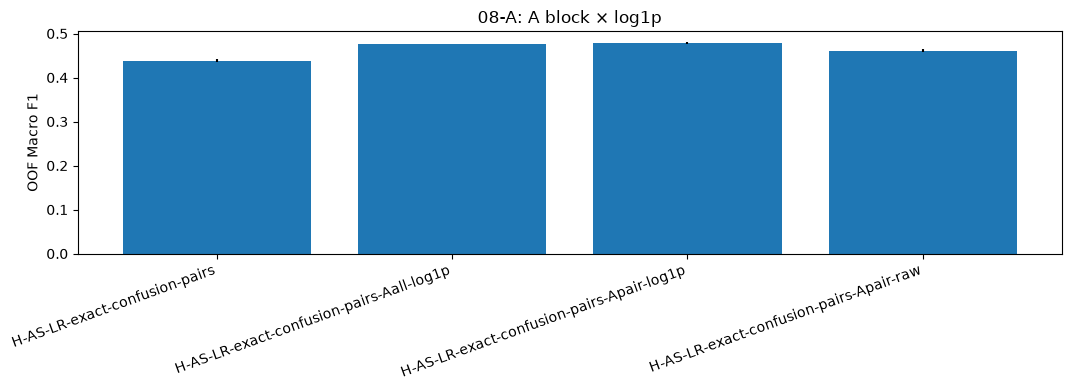

In [3]:
def oof_path(run_id,candidate,seed): return RESULT_DIR/f'{run_id}_{candidate}_{MODEL}_seed{seed}_oof.csv'
sources={A_ALL_RAW:'exp-gs-002-06',A_ALL_LOG:'exp-gs-002-08A',A_PAIR_RAW:'exp-gs-002-08A',A_PAIR_LOG:'exp-gs-002-07'}
paths=[oof_path(sources[c],c,seed) for c in sources for seed in SELECT_SEEDS]
missing=[p for p in paths if not p.exists()]
if missing:
    print('08-A 결과가 부족합니다:'); [print(' -',p.name) for p in missing]
else:
    runs=pd.concat([pd.read_csv(p) for p in paths],ignore_index=True)
    assert runs.leakage_check.all() and (runs.nan_as_mutation_count==0).all()
    factorial_summary=runs.groupby('experiment_id',as_index=False).agg(seed_count=('seed','nunique'),macro_f1_mean=('oof_macro_f1','mean'),macro_f1_std=('oof_macro_f1','std'),feature_count_mean=('feature_count_mean','mean'),convergence_warning_count=('convergence_warning_count','sum'))
    factorial_summary['delta_vs_Aall_raw']=factorial_summary.macro_f1_mean-factorial_summary.loc[factorial_summary.experiment_id.eq(A_ALL_RAW),'macro_f1_mean'].iloc[0]
    factorial_summary.to_csv(RESULT_DIR/'exp-gs-002-08A_factorial_summary.csv',index=False)
    display(factorial_summary.sort_values('macro_f1_mean',ascending=False))
    plt.figure(figsize=(11,4)); plt.bar(factorial_summary.experiment_id,factorial_summary.macro_f1_mean,yerr=factorial_summary.macro_f1_std); plt.xticks(rotation=20,ha='right'); plt.ylabel('OOF Macro F1'); plt.title('08-A: A block × log1p'); plt.tight_layout(); plt.show()

## 08-B — 08B-1. 승자 잠금 및 새 seed 실행

In [6]:
import json

STABILITY_WINNER = 'H-AS-LR-exact-confusion-pairs-Apair-log1p'
STABILITY_CONTROL = 'H-AS-LR-exact-confusion-pairs-Aall-log1p'
RUN_STABILITY = True

# 08A 이후 후보/파라미터를 바꾸지 않았다는 재현성 기록
LOCK_PATH = RESULT_DIR / 'exp-gs-002-08B_winner_lock.json'
winner_lock = {
    'selected_from': 'exp-gs-002-08A',
    'winner': STABILITY_WINNER,
    'control': STABILITY_CONTROL,
    'model': MODEL,
    'validation_seeds': list(VALIDATION_SEEDS),
    'fixed_rule': (
        '08B에서는 새 피처·파라미터 탐색 없이, '
        '08A에서 확정한 winner/control만 새 seed로 재평가한다.'
    ),
}

if LOCK_PATH.exists():
    with LOCK_PATH.open(encoding='utf-8') as f:
        saved_lock = json.load(f)
    assert saved_lock == winner_lock, (
        '기존 winner lock과 현재 설정이 다릅니다. '
        '08B 검증 중에는 후보·파라미터를 변경하지 않습니다.'
    )
else:
    with LOCK_PATH.open('w', encoding='utf-8') as f:
        json.dump(winner_lock, f, ensure_ascii=False, indent=2)

if RUN_STABILITY:
    assert STABILITY_WINNER == A_PAIR_LOG
    assert STABILITY_CONTROL == A_ALL_LOG

    jobs = [
        (candidate, seed)
        for candidate in (STABILITY_CONTROL, STABILITY_WINNER)
        for seed in VALIDATION_SEEDS
    ]

    for candidate, seed in tqdm(
        jobs,
        desc='08-B | locked fresh-seed validation',
        unit='run'
    ):
        output_path = oof_path('exp-gs-002-08B', candidate, seed)

        if output_path.exists():
            print(f'[skip] 이미 존재: {output_path.name}')
            continue

        cmd = [
            sys.executable, str(RUNNER),
            '--run-id', 'exp-gs-002-08B',
            '--candidate', candidate,
            '--model', MODEL,
            '--seed', str(seed),
        ]
        done = subprocess.run(cmd, cwd=ROOT, check=False)

        if done.returncode != 0:
            raise RuntimeError(
                f'{candidate}, seed={seed} 실행 실패: {done.returncode}'
            )

row-local mutation cache: 100%|██████████| 4384/4384 [00:11<00:00, 388.06it/s]
H-AS-LR-exact-confusion-pairs-Aall-log1p | logistic | seed 52: 100%|██████████| 5/5 [03:43<00:00, 44.71s/it]


{
  "experiment_id": "H-AS-LR-exact-confusion-pairs-Aall-log1p",
  "model": "logistic",
  "seed": 52,
  "oof_macro_f1": 0.472688638537702,
  "oof_accuracy": 0.45557168198677633,
  "fold_macro_f1_mean": 0.47241898844972763,
  "fold_macro_f1_std": 0.01797192815644982,
  "feature_count_mean": 8216.6,
  "runtime_seconds": 223.64804895799898,
  "convergence_warning_count": 0,
  "leakage_check": true,
  "nan_as_mutation_count": 0
}


row-local mutation cache: 100%|██████████| 4384/4384 [00:11<00:00, 387.63it/s]s/run]
H-AS-LR-exact-confusion-pairs-Aall-log1p | logistic | seed 62: 100%|██████████| 5/5 [03:36<00:00, 43.35s/it]


{
  "experiment_id": "H-AS-LR-exact-confusion-pairs-Aall-log1p",
  "model": "logistic",
  "seed": 62,
  "oof_macro_f1": 0.4720590425927394,
  "oof_accuracy": 0.4533139816158684,
  "fold_macro_f1_mean": 0.4710672201199387,
  "fold_macro_f1_std": 0.015188880336277868,
  "feature_count_mean": 8216.8,
  "runtime_seconds": 216.8342094999971,
  "convergence_warning_count": 0,
  "leakage_check": true,
  "nan_as_mutation_count": 0
}


row-local mutation cache: 100%|██████████| 4384/4384 [00:10<00:00, 401.26it/s]s/run]
H-AS-LR-exact-confusion-pairs-Aall-log1p | logistic | seed 31415: 100%|██████████| 5/5 [03:38<00:00, 43.65s/it]


...

row-local mutation cache: 100%|██████████| 4384/4384 [00:10<00:00, 401.90it/s]s/run]
H-AS-LR-exact-confusion-pairs-Apair-log1p | logistic | seed 62: 100%|██████████| 5/5 [02:59<00:00, 35.82s/it]


{
  "experiment_id": "H-AS-LR-exact-confusion-pairs-Apair-log1p",
  "model": "logistic",
  "seed": 62,
  "oof_macro_f1": 0.4766154231818713,
  "oof_accuracy": 0.457990646669892,
  "fold_macro_f1_mean": 0.4753088106574149,
  "fold_macro_f1_std": 0.008419924609365373,
  "feature_count_mean": 8170.8,
  "runtime_seconds": 179.16155591699498,
  "convergence_warning_count": 0,
  "leakage_check": true,
  "nan_as_mutation_count": 0
}


row-local mutation cache: 100%|██████████| 4384/4384 [00:10<00:00, 400.81it/s]s/run]
H-AS-LR-exact-confusion-pairs-Apair-log1p | logistic | seed 31415: 100%|██████████| 5/5 [03:08<00:00, 37.62s/it]


{
  "experiment_id": "H-AS-LR-exact-confusion-pairs-Apair-log1p",
  "model": "logistic",
  "seed": 31415,
  "oof_macro_f1": 0.4790272791349962,
  "oof_accuracy": 0.45879696823093047,
  "fold_macro_f1_mean": 0.4776834243342322,
  "fold_macro_f1_std": 0.007595538863581789,
  "feature_count_mean": 8169.2,
  "runtime_seconds": 188.1979707499995,
  "convergence_warning_count": 0,
  "leakage_check": true,
  "nan_as_mutation_count": 0
}


08-B | locked fresh-seed validation: 100%|██████████| 6/6 [22:59<00:00, 229.94s/run]


## 08B-2. 성능·누수·NaN·수렴 경고 검증

In [ ]:
paths = [
    oof_path('exp-gs-002-08B', candidate, seed)
    for candidate in (STABILITY_CONTROL, STABILITY_WINNER)
    for seed in VALIDATION_SEEDS
]
missing = [path for path in paths if not path.exists()]

if missing:
    print('08B 결과가 아직 부족합니다.')
    for path in missing:
        print(' -', path.name)
else:
    runs = pd.concat([pd.read_csv(path) for path in paths], ignore_index=True)

    # 새 seed 전체에 대한 필수 안전성 조건
    assert runs['leakage_check'].all(), 'leakage_check=False 결과가 있습니다.'
    assert (runs['nan_as_mutation_count'] == 0).all(), (
        'NaN이 mutation으로 처리된 결과가 있습니다.'
    )
    assert (runs['convergence_warning_count'] == 0).all(), (
        '새 seed에서 수렴 경고가 발생했습니다.'
    )

    stability = (
        runs.groupby('experiment_id', as_index=False)
        .agg(
            seed_count=('seed', 'nunique'),
            macro_f1_mean=('oof_macro_f1', 'mean'),
            macro_f1_std=('oof_macro_f1', 'std'),
            accuracy_mean=('oof_accuracy', 'mean'),
            feature_count_mean=('feature_count_mean', 'mean'),
            convergence_warning_count=('convergence_warning_count', 'sum'),
        )
    )

    control_score = stability.loc[
        stability['experiment_id'].eq(STABILITY_CONTROL),
        'macro_f1_mean'
    ].iloc[0]

    stability['delta_vs_Aall_log1p'] = (
        stability['macro_f1_mean'] - control_score
    )

    stability.to_csv(
        RESULT_DIR / 'exp-gs-002-08B_fresh_seed_summary.csv',
        index=False
    )

    display(stability.sort_values('macro_f1_mean', ascending=False))

08-A 완료 후 STABILITY_WINNER를 설정하세요.


## 08B-3. 혼동쌍 선택 유전자 감사 및 빈도 저장
이 셀은 test를 읽지 않고, 각 새 seed의 fold-train 데이터와 label만 사용해 실제 선택 규칙을 재현합니다.

In [7]:
import importlib.util
import numpy as np

# 공통 실행기의 동일한 파서·선택 규칙만 사용
module_name = 'exp_gs_002_runner_audit'
spec = importlib.util.spec_from_file_location(module_name, RUNNER)
runner_module = importlib.util.module_from_spec(spec)
sys.modules[module_name] = runner_module
spec.loader.exec_module(runner_module)

train_path = ROOT / 'data' / 'raw' / 'train.csv'
train_frame = pd.read_csv(train_path)

id_col = runner_module.CONFIG.id_col
target_col = runner_module.CONFIG.target_col
genes = [
    column for column in train_frame.columns
    if column not in (id_col, target_col)
]

assert int(train_frame[genes].isna().sum().sum()) == 0
assert runner_module.CANDIDATES[STABILITY_WINNER].contrast_pairs

# test는 로드·조회하지 않는다.
cache = runner_module.RowCache.build(train_frame[genes], genes)
labels = train_frame[target_col].to_numpy()
audit_rows = []

for seed in tqdm(
    VALIDATION_SEEDS,
    desc='08-B | confusion-pair selection audit',
    unit='seed'
):
    splitter = runner_module.StratifiedKFold(
        n_splits=runner_module.CONFIG.n_splits,
        shuffle=True,
        random_state=seed,
    )

    for fold, (train_index, _) in enumerate(
        splitter.split(np.zeros(len(labels)), labels),
        start=1,
    ):
        fold_labels = labels[train_index]

        for left, right, top_k in runner_module.CONTRAST_PAIRS:
            left_mask = fold_labels == left
            right_mask = fold_labels == right

            assert left_mask.any() and right_mask.any()

            left_counts = np.asarray(
                cache.mutation_matrix[train_index][left_mask].getnnz(axis=0)
            ).ravel()
            right_counts = np.asarray(
                cache.mutation_matrix[train_index][right_mask].getnnz(axis=0)
            ).ravel()

            support = left_counts + right_counts
            contrast = (
                left_counts / left_mask.sum()
                - right_counts / right_mask.sum()
            )
            eligible = np.flatnonzero(support >= 10)

            selected = sorted(
                eligible,
                key=lambda index: (
                    -abs(contrast[index]),
                    -support[index],
                    cache.genes[index],
                ),
            )[:top_k]

            for rank, index in enumerate(selected, start=1):
                audit_rows.append({
                    'seed': seed,
                    'fold': fold,
                    'cancer_pair': f'{left}_vs_{right}',
                    'rank': rank,
                    'gene': cache.genes[index],
                    'support': int(support[index]),
                    'left_mutation_rate': float(
                        left_counts[index] / left_mask.sum()
                    ),
                    'right_mutation_rate': float(
                        right_counts[index] / right_mask.sum()
                    ),
                    'signed_contrast': float(contrast[index]),
                    'selection_source': 'fold_train_only',
                })

selection_audit = pd.DataFrame(audit_rows)
expected_rows = (
    len(VALIDATION_SEEDS)
    * runner_module.CONFIG.n_splits
    * sum(top_k for _, _, top_k in runner_module.CONTRAST_PAIRS)
)
assert len(selection_audit) == expected_rows

selection_frequency = (
    selection_audit
    .groupby(['cancer_pair', 'gene'], as_index=False)
    .agg(
        selection_count=('gene', 'size'),
        seed_count=('seed', 'nunique'),
        fold_count=('fold', 'nunique'),
        mean_rank=('rank', 'mean'),
        mean_abs_contrast=(
            'signed_contrast',
            lambda values: float(np.mean(np.abs(values)))
        ),
    )
)

selection_frequency['selection_rate'] = (
    selection_frequency['selection_count']
    / (len(VALIDATION_SEEDS) * runner_module.CONFIG.n_splits)
)

selection_audit.to_csv(
    RESULT_DIR / 'exp-gs-002-08B_confusion_selection_audit.csv',
    index=False
)
selection_frequency.to_csv(
    RESULT_DIR / 'exp-gs-002-08B_confusion_selection_frequency.csv',
    index=False
)

display(
    selection_frequency.sort_values(
        ['cancer_pair', 'selection_count', 'mean_abs_contrast'],
        ascending=[True, False, False],
    )
)

row-local mutation cache: 100%|██████████| 4384/4384 [00:11<00:00, 381.10it/s]
08-B | confusion-pair selection audit: 100%|██████████| 3/3 [00:00<00:00, 49.68seed/s]


,cancer_pair,gene,selection_count,seed_count,fold_count,mean_rank,mean_abs_contrast,selection_rate
17,KIRC_vs_KIPAN,VHL,15,3,5,1.000000,0.153067,1.000000
15,KIRC_vs_KIPAN,TP53,15,3,5,2.333333,0.031632,1.000000
7,KIRC_vs_KIPAN,MET,11,3,5,4.181818,0.023665,0.733333
1,KIRC_vs_KIPAN,CDC27,9,3,5,3.333333,0.025596,0.600000
3,KIRC_vs_KIPAN,DOCK4,5,3,4,3.800000,0.024721,0.333333
6,KIRC_vs_KIPAN,MAML2,4,3,3,4.250000,0.024853,0.266667
12,KIRC_vs_KIPAN,PKD1,4,3,3,4.250000,0.021688,0.266667
10,KIRC_vs_KIPAN,NEFH,2,2,2,4.000000,0.024272,0.133333
9,KIRC_vs_KIPAN,MYO15A,1,1,1,4.000000,0.025381,0.066667
8,KIRC_vs_KIPAN,MTOR,1,1,1,3.000000,0.024835,0.066667
